In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv('Dataset/Cardiovascular_Disease.csv')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
df['age'] = round(df['age']/365, 2)

In [4]:
pressure = (df['ap_hi'].between(100, 200)) & (df['ap_lo'].between(50, 90))
df = df[pressure]

In [5]:
weight_data = (df['weight'] >= 40) & (df['weight'] <= 140)
df = df[weight_data]

In [6]:
height = (df['height']>=120)
df = df[height]

In [7]:
df_sample = df.sample(n=5000, random_state=42)

In [8]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [9]:
features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [10]:
X = df_sample[features]
Y = df_sample[target]

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [12]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [40]:
model = SVC(
    kernel='rbf', gamma='scale', C = 1.0
)

In [41]:
model.fit(X_train_scale, Y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [42]:
Y_pred = model.predict(X_test_scale)

In [43]:
cr = classification_report(Y_test, Y_pred)
cm = confusion_matrix(Y_test, Y_pred)

In [44]:
print(cr)

              precision    recall  f1-score   support

           0       0.71      0.80      0.75       533
           1       0.73      0.62      0.67       467

    accuracy                           0.72      1000
   macro avg       0.72      0.71      0.71      1000
weighted avg       0.72      0.72      0.71      1000



In [45]:
print(cm)

[[428 105]
 [179 288]]


<Axes: >

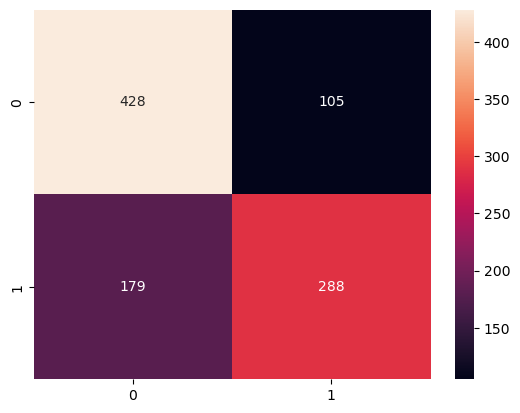

In [46]:
sns.heatmap(cm, annot=True, fmt='.0f')